# Atividade de Controle de Sistemas Dinâmicos

## Sintonia de Controladores P, PI e PID pelo Método de Ziegler-Nichols

Bryan Goulart - 02320205
Diogo Gil de Oliveira - 02320513
Eduardo Peron - 02320356
Emily Colen - 02320114

Neste trabalho foi feito um projeto para analisar uma planta em malha aberta e depois aplicar um controlador.

Primeiro foi definida uma função de transferência para representar o sistema. Em seguida, foi aplicada uma entrada degrau unitário para observar a resposta da planta sem controlador.

A partir dessa resposta, foram encontrados os valores de K, L e T usando a reta tangente no ponto de inflexão da curva.

Depois disso, foi usada a tabela de Ziegler-Nichols para calcular os parâmetros dos controladores P, PI e PID. Por fim, a malha foi fechada para comparar a resposta do sistema com e sem controlador.


In [21]:
# Bibliotecas usadas no projeto

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [22]:
# Definição da planta em malha aberta
# Planta usada: G(s) = 6 / ((s+1)(s+2)(s+3))

num_planta = [6]
den_planta = [1, 6, 11, 6]

planta = signal.TransferFunction(num_planta, den_planta)

print("Planta em malha aberta:")
print(planta)

Planta em malha aberta:
TransferFunctionContinuous(
array([6.]),
array([ 1.,  6., 11.,  6.]),
dt: None
)


## Resposta ao degrau em malha aberta

Nesta parte foi aplicada uma entrada degrau unitário na planta em malha aberta.

A planta ainda está sem controlador. Por isso, esse primeiro gráfico serve para ver como o sistema se comporta sozinho.

Essa resposta será usada para encontrar os valores de K, L e T.

Valor final aproximado da resposta (K): 0.9998638063940906


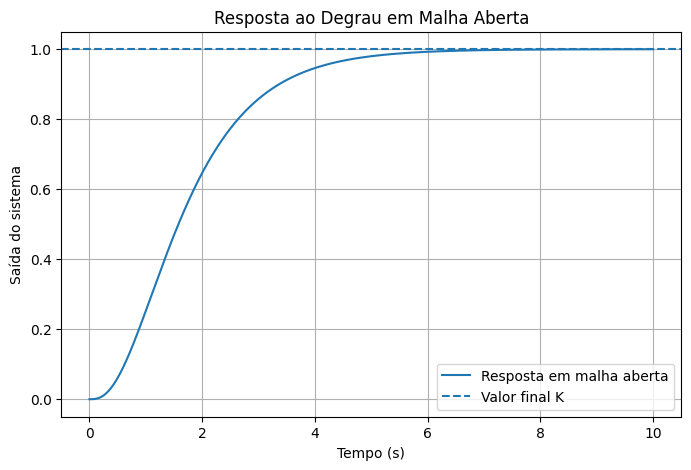

In [23]:
# Resposta ao degrau em malha aberta

# Tempo usado na simulação
tempo = np.linspace(0, 10, 1000)

# Aplicando o degrau unitário na planta
t_malha_aberta, y_malha_aberta = signal.step(planta, T=tempo)

# Valor final aproximado da resposta
K = y_malha_aberta[-1]

print("Valor final aproximado da resposta (K):", K)

# Gráfico da resposta ao degrau
plt.figure(figsize=(8, 5))
plt.plot(t_malha_aberta, y_malha_aberta, label="Resposta em malha aberta")
plt.axhline(K, linestyle="--", label="Valor final K")

plt.title("Resposta ao Degrau em Malha Aberta")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída do sistema")
plt.grid(True)
plt.legend()
plt.show()

## Extração geométrica da curva

Depois da resposta ao degrau, foi feita a parte geométrica do método.

O ponto de inflexão foi aproximado pelo ponto onde a curva tem a maior inclinação. Nesse ponto foi traçada uma reta tangente.

Com essa reta, foram encontrados os valores:

* K: valor final da resposta;
* L: tempo de atraso;
* T: constante de tempo.

Esses valores serão usados depois para calcular o controlador.

In [24]:
# Encontrando o ponto de maior inclinação da curva

# Derivada aproximada da saída
derivada = np.gradient(y_malha_aberta, t_malha_aberta)

# Posição onde a derivada é máxima
indice_inflexao = np.argmax(derivada)

# Valores do ponto de inflexão
t_inflexao = t_malha_aberta[indice_inflexao]
y_inflexao = y_malha_aberta[indice_inflexao]

# Inclinação da reta tangente
inclinacao = derivada[indice_inflexao]

# Equação da reta tangente
reta_tangente = y_inflexao + inclinacao * (t_malha_aberta - t_inflexao)

# Cálculo de L: onde a reta tangente corta o eixo x
L = t_inflexao - (y_inflexao / inclinacao)

# Cálculo do ponto onde a reta tangente encontra o valor final K
tempo_cruza_K = t_inflexao + ((K - y_inflexao) / inclinacao)

# Cálculo de T
T = tempo_cruza_K - L

print("Ponto de inflexão:")
print("Tempo:", t_inflexao)
print("Saída:", y_inflexao)

print("\nParâmetros encontrados:")
print("K =", K)
print("L =", L)
print("T =", T)

Ponto de inflexão:
Tempo: 1.1011011011011012
Saída: 0.29740243344462697

Parâmetros encontrados:
K = 0.9998638063940906
L = 0.431925842669973
T = 2.249760075229085


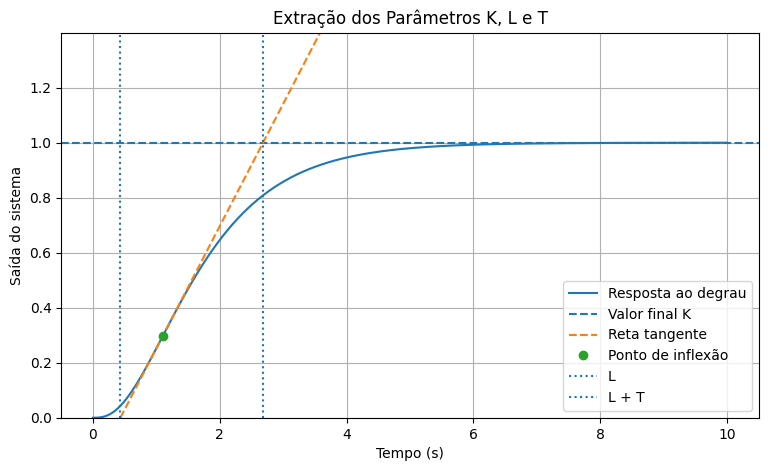

In [25]:
# Gráfico mais limpo da extração geométrica

plt.figure(figsize=(9, 5))

# Curva da resposta ao degrau
plt.plot(t_malha_aberta, y_malha_aberta, label="Resposta ao degrau")

# Valor final K
plt.axhline(K, linestyle="--", label="Valor final K")

# Reta tangente mostrada só na parte importante
tempo_tangente = np.linspace(L, tempo_cruza_K + 1, 200)
reta_tangente_menor = y_inflexao + inclinacao * (tempo_tangente - t_inflexao)

plt.plot(tempo_tangente, reta_tangente_menor, linestyle="--", label="Reta tangente")

# Ponto de inflexão
plt.plot(t_inflexao, y_inflexao, "o", label="Ponto de inflexão")

# Marcações de L e L + T
plt.axvline(L, linestyle=":", label="L")
plt.axvline(tempo_cruza_K, linestyle=":", label="L + T")

plt.title("Extração dos Parâmetros K, L e T")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída do sistema")
plt.grid(True)
plt.legend()
plt.ylim(0, K * 1.4)
plt.show()

## Tabela de Ziegler-Nichols

Com os valores de L e T encontrados na curva, foi usada a tabela de Ziegler-Nichols.

Essa tabela ajuda a calcular os parâmetros do controlador de acordo com o tipo escolhido: P, PI ou PID.

A tabela usada foi:

| Controlador | Kp | Ti | Td |
|---|---|---|---|
| P | T / L | - | - |
| PI | 0,9 . T / L | L / 0,3 | - |
| PID | 1,2 . T / L | 2 . L | 0,5 . L |

Neste projeto, foi escolhido um controlador para o exemplo principal, mas também foi feita uma comparação entre P, PI e PID.


In [26]:
# Escolha do controlador
# Opções: "P", "PI" ou "PID"

tipo_controlador = "PID"

# Cálculo dos parâmetros pela tabela de Ziegler-Nichols

if tipo_controlador == "P":
    Kp = T / L
    Ti = None
    Td = None

elif tipo_controlador == "PI":
    Kp = 0.9 * T / L
    Ti = L / 0.3
    Td = None

elif tipo_controlador == "PID":
    Kp = 1.2 * T / L
    Ti = 2 * L
    Td = 0.5 * L

else:
    print("Tipo de controlador inválido. Escolha P, PI ou PID.")

print("Controlador escolhido:", tipo_controlador)
print("Kp =", Kp)
print("Ti =", Ti)
print("Td =", Td)

Controlador escolhido: PID
Kp = 6.2504064901198895
Ti = 0.863851685339946
Td = 0.2159629213349865


## Montagem do controlador e fechamento da malha

Depois de calcular os parâmetros do controlador, foi montada a função do controlador escolhido.

Quando o controlador é colocado no sistema, a malha precisa ser fechada. Para isso foi usada realimentação negativa.

A função de transferência em malha fechada fica:

T(s) = C(s)G(s) / (1 + C(s)G(s))

Com isso, foi possível analisar a resposta do sistema já com o controlador.


In [27]:
# Montagem do controlador escolhido

if tipo_controlador == "P":
    num_controlador = [Kp]
    den_controlador = [1]

elif tipo_controlador == "PI":
    # C(s) = Kp * (Ti*s + 1) / (Ti*s)
    num_controlador = [Kp * Ti, Kp]
    den_controlador = [Ti, 0]

elif tipo_controlador == "PID":
    # C(s) = Kp * (Td*Ti*s² + Ti*s + 1) / (Ti*s)
    num_controlador = [Kp * Td * Ti, Kp * Ti, Kp]
    den_controlador = [Ti, 0]

controlador = signal.TransferFunction(num_controlador, den_controlador)

print("Controlador:")
print(controlador)

Controlador:
TransferFunctionContinuous(
array([1.34985605, 6.25040649, 7.23550882]),
array([1., 0.]),
dt: None
)


In [28]:
# Fechamento da malha com realimentação negativa

# Multiplicando C(s) por G(s)
num_malha_aberta_controlada = np.polymul(num_controlador, num_planta)
den_malha_aberta_controlada = np.polymul(den_controlador, den_planta)

# Para fazer 1 + C(s)G(s), somamos os polinômios do denominador e numerador
def soma_polinomios(p1, p2):
    if len(p1) > len(p2):
        p2 = np.pad(p2, (len(p1) - len(p2), 0))
    elif len(p2) > len(p1):
        p1 = np.pad(p1, (len(p2) - len(p1), 0))
    return p1 + p2

num_malha_fechada = num_malha_aberta_controlada
den_malha_fechada = soma_polinomios(den_malha_aberta_controlada, num_malha_aberta_controlada)

malha_fechada = signal.TransferFunction(num_malha_fechada, den_malha_fechada)

print("Sistema em malha fechada com controlador:")
print(malha_fechada)


Sistema em malha fechada com controlador:
TransferFunctionContinuous(
array([ 8.09913627, 37.50243894, 43.41305293]),
array([ 1.        ,  6.        , 19.09913627, 43.50243894, 43.41305293]),
dt: None
)


## Comparação com e sem controlador

Nesta parte foi comparada a resposta da planta sem controlador com a resposta do sistema usando controlador.

Também foi feita uma verificação dos polos da malha fechada. Se todos os polos tiverem parte real negativa, o sistema é considerado estável.

Essa comparação ajuda a ver o efeito do controlador na saída do sistema.


In [29]:
# Verificação dos polos da malha fechada

polos_malha_fechada = np.roots(den_malha_fechada)

print("Polos da malha fechada:")
print(polos_malha_fechada)

# Verifica se todos os polos têm parte real negativa
if np.all(np.real(polos_malha_fechada) < 0):
    print("O sistema em malha fechada é estável.")
else:
    print("O sistema em malha fechada não é estável.")

Polos da malha fechada:
[-0.60215243+2.6986211j -0.60215243-2.6986211j -2.66460416+0.j
 -2.13109098+0.j       ]
O sistema em malha fechada é estável.


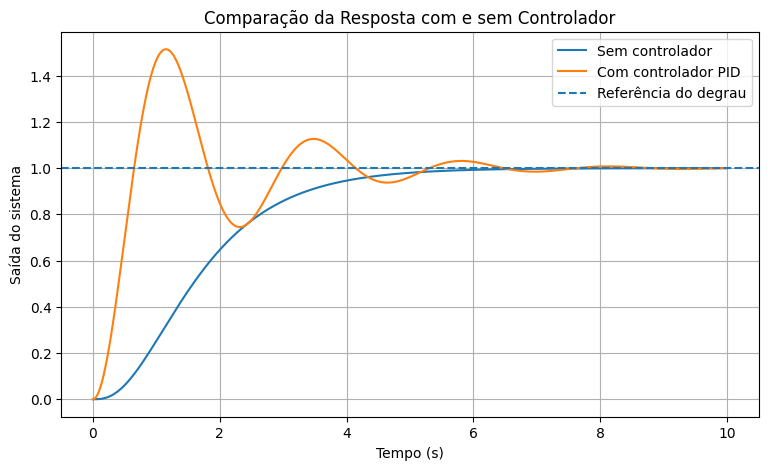

In [30]:
# Resposta ao degrau do sistema com controlador

tempo_comparacao = np.linspace(0, 10, 1000)

# Resposta em malha fechada
t_fechada, y_fechada = signal.step(malha_fechada, T=tempo_comparacao)

# Gráfico comparando sem controlador e com controlador
plt.figure(figsize=(9, 5))

plt.plot(t_malha_aberta, y_malha_aberta, label="Sem controlador")
plt.plot(t_fechada, y_fechada, label="Com controlador " + tipo_controlador)

plt.axhline(1, linestyle="--", label="Referência do degrau")

plt.title("Comparação da Resposta com e sem Controlador")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída do sistema")
plt.grid(True)
plt.legend()
plt.show()

## Teste com diferentes entradas

Depois de fechar a malha com o controlador, foram testadas três entradas diferentes:

* degrau;
* rampa;
* parábola.

A ideia foi observar como o sistema controlado responde para cada tipo de entrada.

Esses testes ajudam a ver se o controlador funciona bem em situações diferentes.


In [31]:
# Testando o sistema em malha fechada com degrau, rampa e parábola

tempo_testes = np.linspace(0, 10, 1000)

# Entradas
entrada_degrau = np.ones_like(tempo_testes)
entrada_rampa = tempo_testes
entrada_parabola = tempo_testes**2

# Respostas do sistema
t1, y_degrau, x1 = signal.lsim(malha_fechada, U=entrada_degrau, T=tempo_testes)
t2, y_rampa, x2 = signal.lsim(malha_fechada, U=entrada_rampa, T=tempo_testes)
t3, y_parabola, x3 = signal.lsim(malha_fechada, U=entrada_parabola, T=tempo_testes)

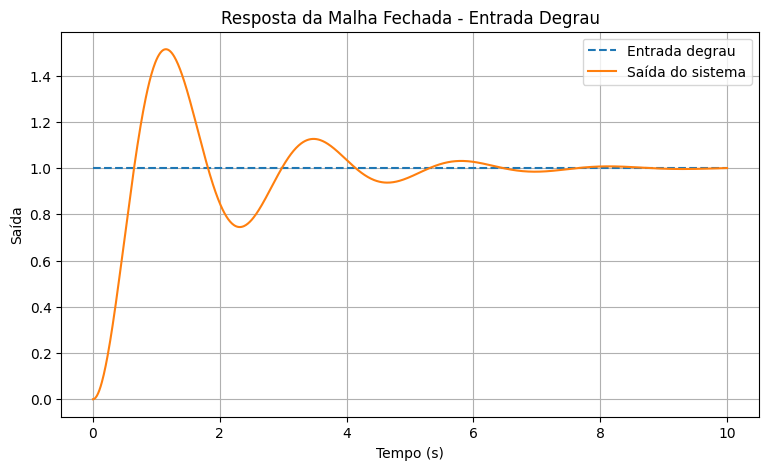

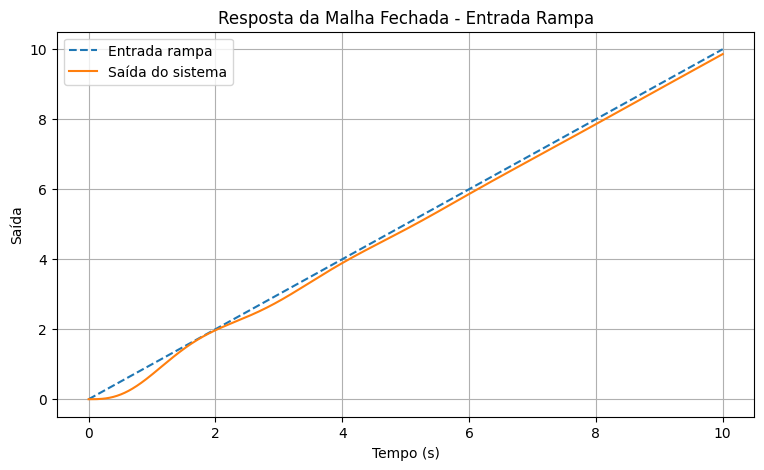

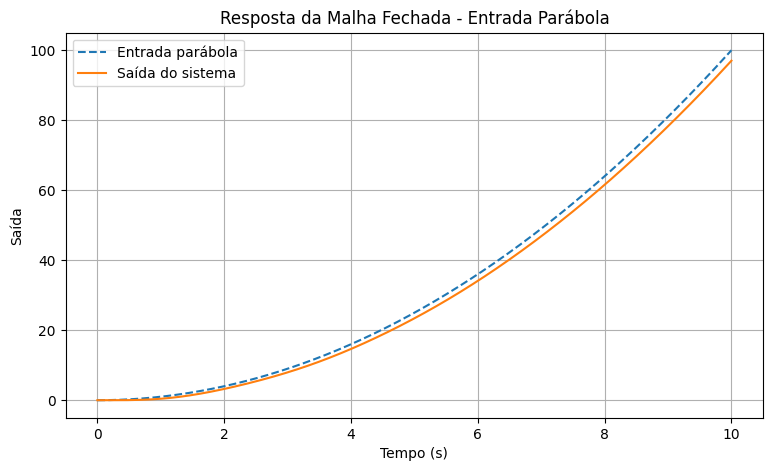

In [32]:
# Gráfico da resposta para entrada degrau

plt.figure(figsize=(9, 5))
plt.plot(tempo_testes, entrada_degrau, linestyle="--", label="Entrada degrau")
plt.plot(t1, y_degrau, label="Saída do sistema")

plt.title("Resposta da Malha Fechada - Entrada Degrau")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.grid(True)
plt.legend()
plt.show()


# Gráfico da resposta para entrada rampa

plt.figure(figsize=(9, 5))
plt.plot(tempo_testes, entrada_rampa, linestyle="--", label="Entrada rampa")
plt.plot(t2, y_rampa, label="Saída do sistema")

plt.title("Resposta da Malha Fechada - Entrada Rampa")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.grid(True)
plt.legend()
plt.show()


# Gráfico da resposta para entrada parábola

plt.figure(figsize=(9, 5))
plt.plot(tempo_testes, entrada_parabola, linestyle="--", label="Entrada parábola")
plt.plot(t3, y_parabola, label="Saída do sistema")

plt.title("Resposta da Malha Fechada - Entrada Parábola")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída")
plt.grid(True)
plt.legend()
plt.show()

## Análise dos resultados

Na resposta em malha aberta, o sistema chegou em um valor final depois de um certo tempo.

Com o gráfico da resposta, foi possível traçar a reta tangente e encontrar os valores de K, L e T. Esses valores foram usados na tabela de Ziegler-Nichols para calcular os parâmetros do controlador.

Na comparação com e sem controlador, deu para perceber que o controlador mudou a resposta do sistema. No exemplo com PID, a resposta ficou mais rápida, mas teve uma ultrapassagem no começo e depois estabilizou.

Nos testes com degrau, rampa e parábola, foi possível observar que a saída do sistema muda de acordo com o tipo de entrada aplicada.

In [33]:
# Função para somar polinômios com tamanhos diferentes
def soma_polinomios(p1, p2):
    if len(p1) > len(p2):
        p2 = np.pad(p2, (len(p1) - len(p2), 0))
    elif len(p2) > len(p1):
        p1 = np.pad(p1, (len(p2) - len(p1), 0))
    return p1 + p2


# Função para calcular os parâmetros do controlador
def calcular_parametros(tipo, L, T):
    if tipo == "P":
        Kp = T / L
        Ti = None
        Td = None

    elif tipo == "PI":
        Kp = 0.9 * T / L
        Ti = L / 0.3
        Td = None

    elif tipo == "PID":
        Kp = 1.2 * T / L
        Ti = 2 * L
        Td = 0.5 * L

    return Kp, Ti, Td


# Função para montar o controlador
def montar_controlador(tipo, Kp, Ti, Td):
    if tipo == "P":
        num_controlador = [Kp]
        den_controlador = [1]

    elif tipo == "PI":
        num_controlador = [Kp * Ti, Kp]
        den_controlador = [Ti, 0]

    elif tipo == "PID":
        num_controlador = [Kp * Td * Ti, Kp * Ti, Kp]
        den_controlador = [Ti, 0]

    return num_controlador, den_controlador


# Função para fechar a malha
def fechar_malha(num_controlador, den_controlador):
    num_malha_aberta = np.polymul(num_controlador, num_planta)
    den_malha_aberta = np.polymul(den_controlador, den_planta)

    num_malha_fechada = num_malha_aberta
    den_malha_fechada = soma_polinomios(den_malha_aberta, num_malha_aberta)

    sistema_fechado = signal.TransferFunction(num_malha_fechada, den_malha_fechada)

    return sistema_fechado, den_malha_fechada

## Comparação entre controladores P, PI e PID

Nesta parte foram testados os três controladores: P, PI e PID.

O objetivo foi comparar as respostas e ver como cada tipo de controlador muda o comportamento do sistema.

Assim, além do exemplo principal, também foi possível mostrar que o projeto consegue trabalhar com mais de uma arquitetura de controlador.

Controlador: P
Kp = 5.2086720750999085
Ti = None
Td = None
Polos: [-5.25565687+0.j         -0.37217156+2.63618593j -0.37217156-2.63618593j]
Sistema estável
----------------------------------
Controlador: PI
Kp = 4.687804867589918
Ti = 1.43975280889991
Td = None
Polos: [-5.00868263+0.j        -0.16054957+2.4070362j -0.16054957-2.4070362j
 -0.67021823+0.j       ]
Sistema estável
----------------------------------
Controlador: PID
Kp = 6.2504064901198895
Ti = 0.863851685339946
Td = 0.2159629213349865
Polos: [-0.60215243+2.6986211j -0.60215243-2.6986211j -2.66460416+0.j
 -2.13109098+0.j       ]
Sistema estável
----------------------------------


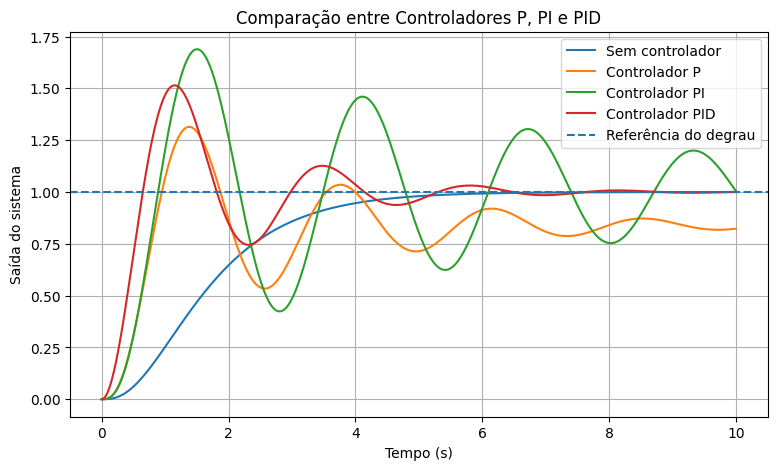

In [34]:
# Comparação entre P, PI e PID

tempo_comparacao = np.linspace(0, 10, 1000)

controladores = ["P", "PI", "PID"]

plt.figure(figsize=(9, 5))

# Resposta sem controlador
plt.plot(t_malha_aberta, y_malha_aberta, label="Sem controlador")

for tipo in controladores:
    Kp_temp, Ti_temp, Td_temp = calcular_parametros(tipo, L, T)

    num_c, den_c = montar_controlador(tipo, Kp_temp, Ti_temp, Td_temp)

    sistema_fechado, den_fechada = fechar_malha(num_c, den_c)

    t_resp, y_resp = signal.step(sistema_fechado, T=tempo_comparacao)

    plt.plot(t_resp, y_resp, label="Controlador " + tipo)

    print("Controlador:", tipo)
    print("Kp =", Kp_temp)
    print("Ti =", Ti_temp)
    print("Td =", Td_temp)

    polos = np.roots(den_fechada)
    print("Polos:", polos)

    if np.all(np.real(polos) < 0):
        print("Sistema estável")
    else:
        print("Sistema instável")

    print("----------------------------------")


plt.axhline(1, linestyle="--", label="Referência do degrau")

plt.title("Comparação entre Controladores P, PI e PID")
plt.xlabel("Tempo (s)")
plt.ylabel("Saída do sistema")
plt.grid(True)
plt.legend()
plt.show()

## Comentário sobre a comparação dos controladores

Na comparação entre P, PI e PID, foi possível ver que cada controlador interfere de um jeito na resposta do sistema.

O controlador P é o mais simples, pois usa apenas o ganho proporcional.

O controlador PI usa o ganho proporcional e também a parte integral. Essa parte integral ajuda a melhorar o erro em regime permanente.

O controlador PID usa a parte proporcional, integral e derivativa. No exemplo usado, ele deixou a resposta mais rápida, mas também teve uma ultrapassagem no início.

Com isso, foi possível perceber que a escolha do controlador influencia diretamente na saída do sistema.

## Conclusão

Neste trabalho foi feita a sintonia de controladores pelo método de Ziegler-Nichols em malha aberta.

Primeiro foi definida uma planta e aplicada uma entrada degrau unitário. Com a resposta obtida, foram encontrados os valores de K, L e T usando a reta tangente no ponto de inflexão.

Depois foram calculados os parâmetros dos controladores P, PI e PID. Em seguida, a malha foi fechada para analisar a resposta do sistema com controlador.

Pelos gráficos, foi possível observar que o controlador altera o comportamento do sistema. No exemplo com PID, a resposta ficou mais rápida, mas teve uma ultrapassagem antes de estabilizar.

Assim, a atividade ajudou a entender melhor como a sintonia de controladores pode ser usada para modificar a resposta de um sistema dinâmico.